![Los Angeles skyline](la_skyline.jpg)

Los Ángeles, California 😎. La Ciudad de los Ángeles. Tinseltown. ¡La Capital Mundial del Entretenimiento!

Conocida por su clima cálido, sus palmeras, su extensa costa y Hollywood, además de ser la cuna de algunas de las películas y canciones más icónicas. Sin embargo, como ocurre en cualquier ciudad densamente poblada, no todo es glamour y puede haber un alto volumen de delincuencia. ¡Ahí es donde entrás vos!

Se te ha pedido colaborar con el Departamento de Policía de Los Ángeles (LAPD) analizando los datos sobre delitos para identificar patrones en el comportamiento criminal. Planean utilizar tus hallazgos para asignar recursos de manera eficiente y combatir los distintos delitos en las diferentes zonas.

Los Datos
Te han facilitado un único conjunto de datos para trabajar. A continuación se presenta un resumen y una vista previa.

Se trata de una versión modificada de los datos originales, los cuales están disponibles públicamente en Los Angeles Open Data.

crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [19]:
#LIBRERIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

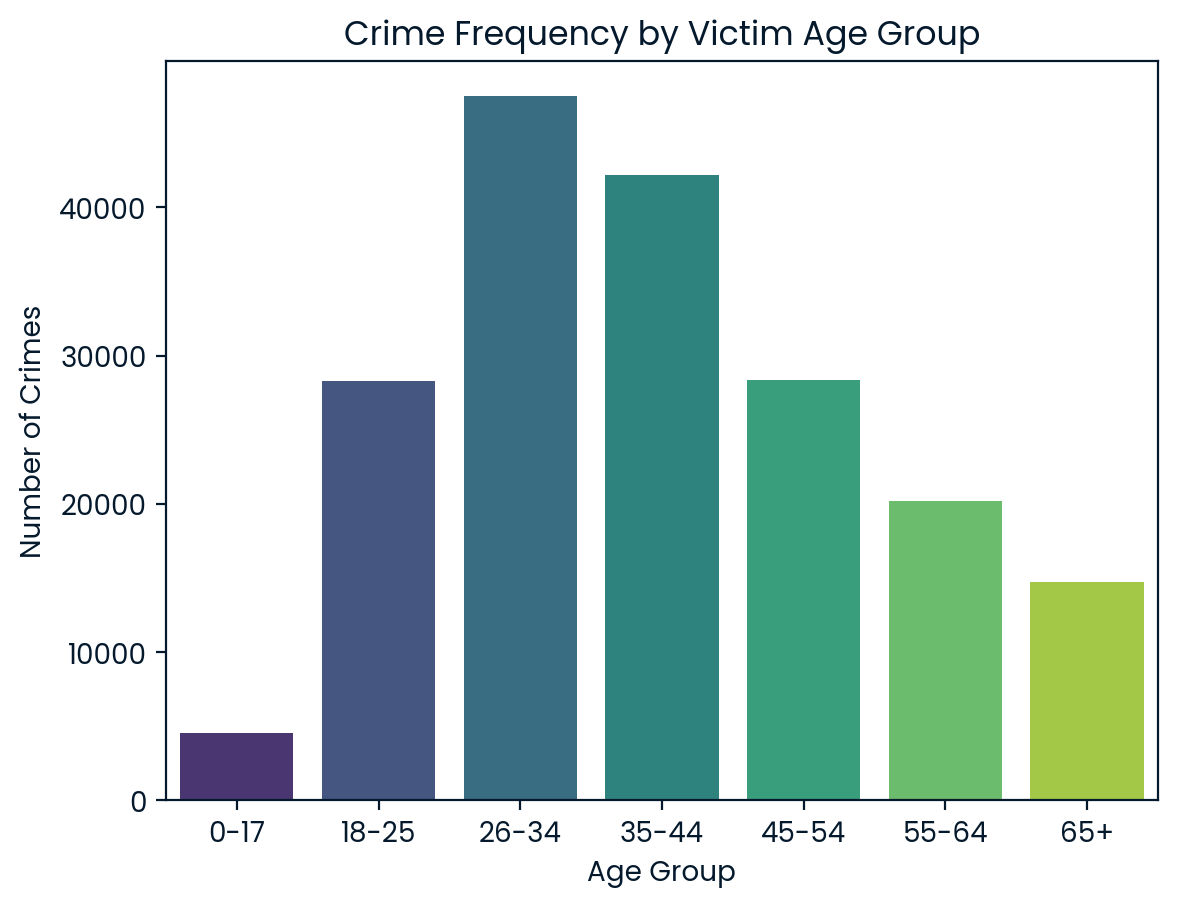

In [20]:
#CODE
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()
crimes["HOUR OCC"]= crimes["TIME OCC"].str[:2].astype(int)
peak_crime_hour= crimes["HOUR OCC"].mode()[0]

night_crimes= crimes[crimes["HOUR OCC"].isin([22, 23, 0, 1, 2, 3])]
peak_night_crime_location= night_crimes["AREA NAME"].value_counts().index[0]

labels=["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]
bins=[-1, 17, 25, 34, 44, 54, 64, np.inf]
crimes["Age_B_Group"]= pd.cut(crimes["Vict Age"], bins=bins, labels=labels)
victim_ages= crimes["Age_B_Group"].value_counts(sort=False)

#VISUALIZATION
sns.barplot(x=victim_ages.index, y=victim_ages.values, palette="viridis")
plt.title("Crime Frequency by Victim Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Crimes")

plt.show()


Análisis de Datos de Criminalidad en Los Ángeles 🚓📊
📌 Descripción General del Proyecto
Este proyecto analiza los datos de delitos de la ciudad de Los Ángeles para descubrir patrones relacionados con los horarios de ocurrencia, las zonas críticas durante la noche y la distribución demográfica de las víctimas según su grupo de edad.

🔑 Hallazgos Clave y Soluciones
1. Hora Pico de Delitos
Objetivo: Identificar la hora del día con mayor frecuencia de delitos cometidos.

Método: Se extrajo la hora a partir de los datos de tiempo (TIME OCC) y se calculó la moda estadística.

Variable Clave: peak_crime_hour

2. Ubicación Principal de Delitos Nocturnos
Objetivo: Encontrar el área geográfica con mayor cantidad de delitos durante el horario nocturno (de 10:00 PM a 3:59 AM).

Método: Se filtró el conjunto de datos para las horas nocturnas [22, 23, 0, 1, 2, 3] y se agruparon los conteos de delitos por zona (AREA NAME).

Variable Clave: peak_night_crime_location

3. Demografía por Edad de las Víctimas
Objetivo: Categorizar a las víctimas en rangos de edad específicos (0-17, 18-25, 26-34, 35-44, 45-54, 55-64, 65+) y calcular sus frecuencias.

Método: Se utilizó pd.cut() para segmentar los datos continuos de edad (Vict Age) en límites personalizados [-1, 17, 25, 34, 44, 54, 64, np.inf] y se generó una tabla de frecuencias manteniendo el orden original de las etiquetas (sort=False).

Variable Clave: victim_ages

🛠️ Herramientas y Librerías Utilizadas
Python

Pandas (Manipulación de datos y segmentación por rangos)

NumPy (Operaciones numéricas y límites)

Matplotlib y Seaborn (Visualización de datos)